# Stage 04 — HELOC XGBoost Model Training

This notebook trains, selects and freezes the HELOC classifier using the Stage 03 cohort, partition and preprocessor. Model selection uses training-only cross-validation; the frozen test set is evaluated only after selection.

## 1. Setup and frozen preprocessor definition

The Stage 03 transformer definition is repeated without behavioural changes so the persisted joblib object can be loaded safely. It is not fitted again in this stage.

In [1]:
from pathlib import Path
import hashlib
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.utils.validation import check_is_fitted
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

class HELOCSpecialValuePreprocessor(BaseEstimator, TransformerMixin):
    """Median-impute HELOC measurements and append training-observed special-code indicators."""
    def __init__(self, feature_names, special_codes=(-7, -8, -9)):
        self.feature_names = feature_names
        self.special_codes = special_codes

    def fit(self, X, y=None):
        frame = self._frame(X)
        self.feature_names_in_ = np.asarray(self.feature_names, dtype=object)
        self.indicator_pairs_ = [
            (feature, int(code)) for feature in self.feature_names for code in self.special_codes
            if frame[feature].eq(code).any()
        ]
        numeric = frame[self.feature_names].mask(frame[self.feature_names].isin(self.special_codes))
        self.imputer_ = SimpleImputer(strategy="median", keep_empty_features=True)
        self.imputer_.fit(numeric)
        self.n_features_in_ = len(self.feature_names)
        return self

    def transform(self, X):
        check_is_fitted(self, ["imputer_", "indicator_pairs_"])
        frame = self._frame(X)
        numeric = frame[self.feature_names].mask(frame[self.feature_names].isin(self.special_codes))
        imputed = self.imputer_.transform(numeric)
        indicators = np.column_stack([
            frame[feature].eq(code).astype(np.int8).to_numpy()
            for feature, code in self.indicator_pairs_
        ]) if self.indicator_pairs_ else np.empty((len(frame), 0), dtype=np.int8)
        return np.hstack([imputed, indicators]).astype(float, copy=False)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["imputer_", "indicator_pairs_"])
        numeric_names = [f"{feature}__numeric_imputed" for feature in self.feature_names]
        indicator_names = [f"{feature}__is_minus{abs(code)}" for feature, code in self.indicator_pairs_]
        return np.asarray(numeric_names + indicator_names, dtype=object)

    def _frame(self, X):
        if isinstance(X, pd.DataFrame):
            missing = set(self.feature_names) - set(X.columns)
            if missing: raise ValueError(f"Missing required features: {sorted(missing)}")
            return X.loc[:, self.feature_names].copy()
        return pd.DataFrame(X, columns=self.feature_names)

## 2. Frozen input verification and matrix reconstruction

Original row indexes reconstruct the exact Stage 03 partitions. The saved preprocessor is used in transform-only mode.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "heloc": PROJECT_ROOT = PROJECT_ROOT.parents[2]
elif PROJECT_ROOT.name == "ml": PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "backend": PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / "backend" / "data" / "heloc" / "raw" / "heloc_raw.csv"
ARTIFACT_DIR = PROJECT_ROOT / "backend" / "artifacts" / "heloc"
PLOT_DIR = ARTIFACT_DIR / "plots"
EXPECTED_HASH = "786b7e1885cf508ef66a968aae65a72bfde198d06d7666ac582958705b092570"
TARGET = "is_at_risk"
RANDOM_STATE = 42
DECISION_THRESHOLD = 0.50

paths = {
    "selection": ARTIFACT_DIR / "selected_features.json",
    "excluded_all9": ARTIFACT_DIR / "excluded_all_minus9_indices.csv",
    "excluded_duplicates": ARTIFACT_DIR / "excluded_duplicate_indices.csv",
    "train_indices": ARTIFACT_DIR / "train_indices.csv",
    "test_indices": ARTIFACT_DIR / "test_indices.csv",
    "preprocessing_metadata": ARTIFACT_DIR / "preprocessing_metadata.json",
    "mapping": ARTIFACT_DIR / "transformed_feature_mapping.csv",
    "preprocessor": ARTIFACT_DIR / "preprocessor.joblib",
    "row_policy": ARTIFACT_DIR / "row_policy.json",
}
for path in paths.values():
    if not path.exists(): raise FileNotFoundError(path)

assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() == EXPECTED_HASH
raw_df = pd.read_csv(RAW_PATH)
selection = json.loads(paths["selection"].read_text(encoding="utf-8"))
preprocessing_metadata = json.loads(paths["preprocessing_metadata"].read_text(encoding="utf-8"))
selected_features = selection["selected_features"]
train_indices = pd.read_csv(paths["train_indices"])["row_index"].astype(int)
test_indices = pd.read_csv(paths["test_indices"])["row_index"].astype(int)
excluded_all9 = pd.read_csv(paths["excluded_all9"])["row_index"].astype(int)
excluded_duplicates = pd.read_csv(paths["excluded_duplicates"])["row_index"].astype(int)
transformed_mapping = pd.read_csv(paths["mapping"])

preprocessor_hash = hashlib.sha256(paths["preprocessor"].read_bytes()).hexdigest()
preprocessor = joblib.load(paths["preprocessor"])
assert isinstance(preprocessor, HELOCSpecialValuePreprocessor)

X_train_raw = raw_df.loc[train_indices, selected_features].copy()
X_test_raw = raw_df.loc[test_indices, selected_features].copy()
y_train = raw_df.loc[train_indices, TARGET].copy()
y_test = raw_df.loc[test_indices, TARGET].copy()
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)
transformed_feature_names = preprocessor.get_feature_names_out()

assert len(selected_features) == 22 and "estimate_of_risk" not in selected_features
assert X_train_processed.shape == (7_896, 33) and X_test_processed.shape == (1_974, 33)
assert y_train.value_counts().sort_index().to_dict() == {0: 3_788, 1: 4_108}
assert y_test.value_counts().sort_index().to_dict() == {0: 947, 1: 1_027}
assert np.isfinite(X_train_processed).all() and np.isfinite(X_test_processed).all()
assert transformed_feature_names.tolist() == transformed_mapping.transformed_feature.tolist()
assert set(train_indices).isdisjoint(set(test_indices))
assert (set(excluded_all9) | set(excluded_duplicates)).isdisjoint(set(train_indices) | set(test_indices))
print("Custom preprocessor loaded: True")
print("Training matrix:", X_train_processed.shape)
print("Test matrix:", X_test_processed.shape)
print("Preprocessor refitted: False")

Custom preprocessor loaded: True
Training matrix: (7896, 33)
Test matrix: (1974, 33)
Preprocessor refitted: False


## 3. Metrics and baseline XGBoost

The cohort is close to balanced, so no resampling or class weighting is applied. Baseline holdout results are descriptive and are not used for model selection.

In [3]:
def metric_bundle(y_true, probabilities, threshold=DECISION_THRESHOLD):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "accuracy": float(accuracy_score(y_true, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, predictions)),
        "precision_positive": float(precision_score(y_true, predictions, zero_division=0)),
        "recall_positive": float(recall_score(y_true, predictions, zero_division=0)),
        "f1_positive": float(f1_score(y_true, predictions, zero_division=0)),
        "true_negative": int(tn), "false_positive": int(fp), "false_negative": int(fn), "true_positive": int(tp),
        "predicted_class_0_count": int((predictions == 0).sum()),
        "predicted_class_1_count": int((predictions == 1).sum()),
        "predicted_positive_prevalence": float(predictions.mean()),
    }

common_settings = {
    "objective": "binary:logistic", "eval_metric": "logloss", "random_state": RANDOM_STATE,
    "n_jobs": -1, "tree_method": "hist", "scale_pos_weight": 1.0,
}
baseline_params = {
    **common_settings, "n_estimators": 200, "max_depth": 3, "learning_rate": 0.05,
    "min_child_weight": 1, "subsample": 1.0, "colsample_bytree": 1.0,
    "reg_alpha": 0.0, "reg_lambda": 1.0, "gamma": 0.0,
}
baseline_model = XGBClassifier(**baseline_params)
started = time.perf_counter(); baseline_model.fit(X_train_processed, y_train); baseline_training_time = time.perf_counter() - started
baseline_test_probabilities = baseline_model.predict_proba(X_test_processed)[:, 1]
baseline_holdout_descriptive = metric_bundle(y_test, baseline_test_probabilities)
display(pd.DataFrame([baseline_holdout_descriptive]))
print("Baseline holdout role: descriptive only")

,roc_auc,pr_auc,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,true_negative,false_positive,false_negative,true_positive,predicted_class_0_count,predicted_class_1_count,predicted_positive_prevalence
0,0.803561,0.808368,0.73151,0.730163,0.732026,0.763389,0.747378,660,287,243,784,903,1071,0.542553


Baseline holdout role: descriptive only


## 4. Controlled training-only search

Eight randomized configurations are assessed with the same five stratified training folds. ROC-AUC is the refit and primary selection metric.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc", "pr_auc": "average_precision", "balanced_accuracy": "balanced_accuracy",
    "precision_positive": "precision", "recall_positive": "recall", "f1_positive": "f1",
}
search_space = {
    "n_estimators": [150, 250, 350, 450],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.025, 0.05, 0.075, 0.1],
    "min_child_weight": [1, 3, 5, 8],
    "subsample": [0.75, 0.9, 1.0],
    "colsample_bytree": [0.75, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [1.0, 3.0, 5.0, 10.0],
}
search_estimator = XGBClassifier(**common_settings)
search = RandomizedSearchCV(
    search_estimator, search_space, n_iter=8, scoring=scoring, refit="roc_auc", cv=cv,
    random_state=RANDOM_STATE, n_jobs=1, return_train_score=False, verbose=0,
)
search_started = time.perf_counter(); search.fit(X_train_processed, y_train); search_time = time.perf_counter() - search_started

cv_results = pd.DataFrame(search.cv_results_)
result_columns = ["rank_test_roc_auc", "mean_test_roc_auc", "std_test_roc_auc", "mean_test_pr_auc", "std_test_pr_auc",
    "mean_test_balanced_accuracy", "std_test_balanced_accuracy", "mean_test_precision_positive", "mean_test_recall_positive",
    "mean_test_f1_positive", "mean_fit_time", "std_fit_time", "params"]
cv_search_results = cv_results[result_columns].sort_values("rank_test_roc_auc")
cv_search_results.to_csv(ARTIFACT_DIR / "cv_search_results.csv", index=False)
print("Search candidates:", len(cv_search_results))
print("Best parameters:", search.best_params_)
print("Best search CV ROC-AUC:", f"{search.best_score_:.6f}")
display(cv_search_results)

Search candidates: 8
Best parameters: {'subsample': 0.75, 'reg_lambda': 3.0, 'reg_alpha': 0.0, 'n_estimators': 250, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best search CV ROC-AUC: 0.807737


,rank_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_balanced_accuracy,std_test_balanced_accuracy,mean_test_precision_positive,mean_test_recall_positive,mean_test_f1_positive,mean_fit_time,std_fit_time,params
0,1,0.807737,0.012731,0.796436,0.020259,0.739667,0.013929,0.743294,0.766553,0.754697,0.222270,0.011532,"{'subsample': 0.75, 'reg_lambda': 3.0, 'reg_al..."
6,2,0.807511,0.012196,0.797082,0.019546,0.739667,0.013212,0.743245,0.766553,0.754681,0.231164,0.018797,"{'subsample': 0.75, 'reg_lambda': 3.0, 'reg_al..."
3,3,0.806372,0.012890,0.795296,0.021434,0.739220,0.011150,0.743499,0.764603,0.753865,0.300245,0.015878,"{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alp..."
1,4,0.805250,0.013105,0.794934,0.020662,0.737349,0.016259,0.738147,0.771420,0.754389,0.245200,0.010882,"{'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alp..."
5,5,0.804636,0.013165,0.792362,0.021231,0.736321,0.013023,0.740962,0.761441,0.751026,0.192949,0.010408,"{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alp..."
7,6,0.803894,0.013269,0.793128,0.021793,0.736499,0.012128,0.739096,0.766552,0.752536,0.522169,0.011205,"{'subsample': 1.0, 'reg_lambda': 3.0, 'reg_alp..."
4,7,0.801815,0.012989,0.791571,0.020535,0.736216,0.012144,0.739754,0.763875,0.751597,0.412464,0.017551,"{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alp..."
2,8,0.791193,0.011918,0.779417,0.018568,0.728737,0.011366,0.732991,0.756571,0.744545,0.600353,0.039790,"{'subsample': 0.9, 'reg_lambda': 3.0, 'reg_alp..."


## 5. Same-fold model comparison and selection

The baseline and CV-best candidate are compared on identical folds. Selection follows the predeclared ROC-AUC, PR-AUC, balanced-accuracy and simplicity rule.

In [5]:
candidate_estimators = {
    "Baseline XGBoost": XGBClassifier(**baseline_params),
    "CV-best XGBoost": XGBClassifier(**{**common_settings, **search.best_params_}),
}
comparison_rows = []
for model_name, estimator in candidate_estimators.items():
    scores = cross_validate(estimator, X_train_processed, y_train, cv=cv, scoring=scoring, n_jobs=1, return_train_score=False)
    row = {"model": model_name}
    for metric in scoring:
        row[f"mean_{metric}"] = float(scores[f"test_{metric}"].mean())
        row[f"std_{metric}"] = float(scores[f"test_{metric}"].std(ddof=1))
    row["mean_fit_time_seconds"] = float(scores["fit_time"].mean())
    comparison_rows.append(row)
cv_model_comparison = pd.DataFrame(comparison_rows)
cv_model_comparison.to_csv(ARTIFACT_DIR / "cv_model_comparison.csv", index=False)
display(cv_model_comparison)

baseline_cv = cv_model_comparison.set_index("model").loc["Baseline XGBoost"]
best_cv = cv_model_comparison.set_index("model").loc["CV-best XGBoost"]
roc_difference = best_cv.mean_roc_auc - baseline_cv.mean_roc_auc
pr_difference = best_cv.mean_pr_auc - baseline_cv.mean_pr_auc
balanced_difference = best_cv.mean_balanced_accuracy - baseline_cv.mean_balanced_accuracy

if abs(roc_difference) >= 0.005:
    selected_name = "CV-best XGBoost" if roc_difference > 0 else "Baseline XGBoost"
    selection_reason = "Selected by the highest mean training-CV ROC-AUC with a difference of at least 0.005."
elif abs(pr_difference) >= 0.005:
    selected_name = "CV-best XGBoost" if pr_difference > 0 else "Baseline XGBoost"
    selection_reason = "Mean CV ROC-AUC differed by less than 0.005; selected by mean CV PR-AUC."
elif abs(balanced_difference) >= 0.005:
    selected_name = "CV-best XGBoost" if balanced_difference > 0 else "Baseline XGBoost"
    selection_reason = "Mean CV ROC-AUC and PR-AUC differed by less than 0.005; selected by balanced accuracy."
else:
    selected_name = "Baseline XGBoost"
    selection_reason = "CV metrics were effectively tied within 0.005; the simpler baseline was preferred."

selected_cv_row = cv_model_comparison.set_index("model").loc[selected_name]
print("Highest CV ROC-AUC:", f"{cv_model_comparison.mean_roc_auc.max():.6f}")
print("Best baseline/CV candidate:", cv_model_comparison.loc[cv_model_comparison.mean_roc_auc.idxmax(), "model"])
print("Selected final model:", selected_name)
print("Selection reason:", selection_reason)

,model,mean_roc_auc,std_roc_auc,mean_pr_auc,std_pr_auc,mean_balanced_accuracy,std_balanced_accuracy,mean_precision_positive,std_precision_positive,mean_recall_positive,std_recall_positive,mean_f1_positive,std_f1_positive,mean_fit_time_seconds
0,Baseline XGBoost,0.804061,0.014408,0.793497,0.021220,0.737126,0.015941,0.738339,0.015308,0.770447,0.017477,0.754008,0.015089,0.202740
1,CV-best XGBoost,0.807737,0.014233,0.796436,0.022651,0.739667,0.015573,0.743294,0.015453,0.766553,0.016722,0.754697,0.014638,0.208584


Highest CV ROC-AUC: 0.807737
Best baseline/CV candidate: CV-best XGBoost
Selected final model: Baseline XGBoost
Selection reason: CV metrics were effectively tied within 0.005; the simpler baseline was preferred.


## 6. Final fit and frozen holdout evaluation

The selected estimator is fitted once on all training rows. The test set is then evaluated once at the frozen 0.50 threshold and cannot change model selection.

In [6]:
final_model = clone(candidate_estimators[selected_name])
started = time.perf_counter(); final_model.fit(X_train_processed, y_train); final_training_time = time.perf_counter() - started
final_probabilities = final_model.predict_proba(X_test_processed)[:, 1]
final_predictions = (final_probabilities >= DECISION_THRESHOLD).astype(int)
final_metrics = metric_bundle(y_test, final_probabilities)
display(pd.DataFrame([final_metrics]))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, final_predictions, labels=[0, 1]))

,roc_auc,pr_auc,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,true_negative,false_positive,false_negative,true_positive,predicted_class_0_count,predicted_class_1_count,predicted_positive_prevalence
0,0.803561,0.808368,0.73151,0.730163,0.732026,0.763389,0.747378,660,287,243,784,903,1071,0.542553


Confusion matrix [[TN, FP], [FN, TP]]:
[[660 287]
 [243 784]]


## 7. Threshold sensitivity

Threshold results are descriptive. The frozen decision threshold remains 0.50 and is not optimized on the test set.

In [7]:
threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    predictions = (final_probabilities >= threshold).astype(int)
    threshold_rows.append({"threshold": threshold,
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "predicted_positive_count": int(predictions.sum())})
threshold_analysis = pd.DataFrame(threshold_rows)
threshold_analysis.to_csv(ARTIFACT_DIR / "threshold_analysis.csv", index=False)
display(threshold_analysis)

,threshold,precision,recall,f1,balanced_accuracy,predicted_positive_count
0,0.3,0.646273,0.894839,0.750510,0.681844,1422
1,0.4,0.695024,0.843233,0.761989,0.720983,1246
2,0.5,0.732026,0.763389,0.747378,0.730163,1071
3,0.6,0.764130,0.684518,0.722137,0.727687,920
4,0.7,0.821534,0.542356,0.653372,0.707292,678


## 8. Model comparison and diagnostic plots

Test metrics are reported after selection and do not revise it. ROC, precision–recall and confusion-matrix plots summarize frozen holdout behaviour.

,model,cv_roc_auc,test_roc_auc,test_pr_auc,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,training_time_seconds
0,Baseline XGBoost,0.804061,0.803561,0.808368,0.731510,0.730163,0.732026,0.763389,0.747378,0.17778
1,CV-best XGBoost,0.807737,0.804964,0.810914,0.737589,0.736170,0.736744,0.771178,0.753568,0.26240


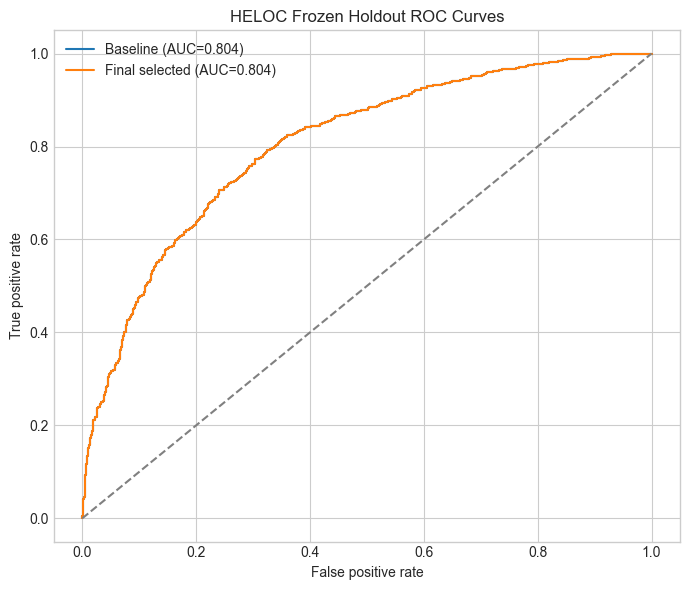

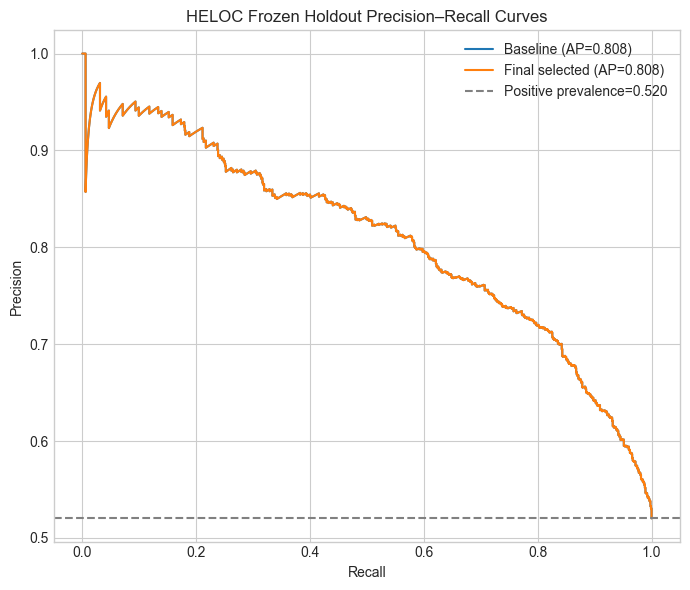

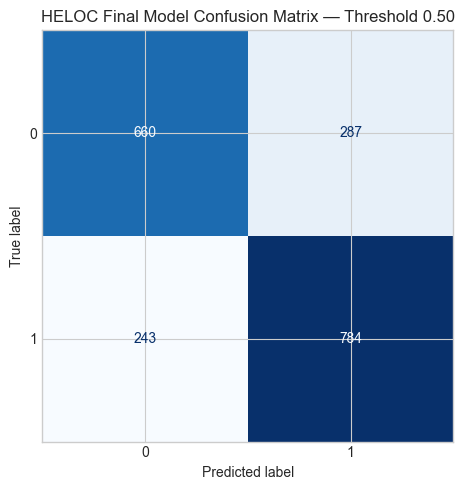

In [8]:
cv_best_holdout_model = clone(candidate_estimators["CV-best XGBoost"])
started = time.perf_counter(); cv_best_holdout_model.fit(X_train_processed, y_train); cv_best_training_time = time.perf_counter() - started
comparison_test_rows = []
for model_name, model, fit_time in [("Baseline XGBoost", baseline_model, baseline_training_time), ("CV-best XGBoost", cv_best_holdout_model, cv_best_training_time)]:
    probabilities = model.predict_proba(X_test_processed)[:, 1]
    metrics = metric_bundle(y_test, probabilities)
    cv_roc = cv_model_comparison.set_index("model").loc[model_name, "mean_roc_auc"]
    comparison_test_rows.append({"model": model_name, "cv_roc_auc": cv_roc,
        "test_roc_auc": metrics["roc_auc"], "test_pr_auc": metrics["pr_auc"], "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"], "precision_positive": metrics["precision_positive"],
        "recall_positive": metrics["recall_positive"], "f1_positive": metrics["f1_positive"],
        "training_time_seconds": fit_time})
model_comparison = pd.DataFrame(comparison_test_rows)
model_comparison.to_csv(ARTIFACT_DIR / "model_comparison.csv", index=False)
display(model_comparison)

fig, ax = plt.subplots(figsize=(7, 6))
for label, probabilities in [("Baseline", baseline_test_probabilities), ("Final selected", final_probabilities)]:
    fpr, tpr, _ = roc_curve(y_test, probabilities); ax.plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_test, probabilities):.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray"); ax.set(title="HELOC Frozen Holdout ROC Curves", xlabel="False positive rate", ylabel="True positive rate"); ax.legend()
plt.tight_layout(); plt.savefig(PLOT_DIR / "heloc_roc_curves.png", dpi=300); plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
for label, probabilities in [("Baseline", baseline_test_probabilities), ("Final selected", final_probabilities)]:
    precision, recall, _ = precision_recall_curve(y_test, probabilities); ax.plot(recall, precision, label=f"{label} (AP={average_precision_score(y_test, probabilities):.3f})")
ax.axhline(y_test.mean(), linestyle="--", color="gray", label=f"Positive prevalence={y_test.mean():.3f}")
ax.set(title="HELOC Frozen Holdout Precision–Recall Curves", xlabel="Recall", ylabel="Precision"); ax.legend()
plt.tight_layout(); plt.savefig(PLOT_DIR / "heloc_precision_recall_curves.png", dpi=300); plt.show()

fig, ax = plt.subplots(figsize=(6, 5)); ConfusionMatrixDisplay.from_predictions(y_test, final_predictions, labels=[0, 1], cmap="Blues", ax=ax, colorbar=False)
ax.set_title("HELOC Final Model Confusion Matrix — Threshold 0.50")
plt.tight_layout(); plt.savefig(PLOT_DIR / "heloc_confusion_matrix.png", dpi=300); plt.show()

## 9. Built-in XGBoost importance sanity check

Built-in importance is reported only as a model diagnostic. SHAP will provide the formal explanation analysis in Stage 05.

,rank,transformed_feature,importance,original_feature,display_feature,representation_type,special_code,readable_label
0,1,net_fraction_of_revolving_burden__numeric_imputed,0.181071,net_fraction_of_revolving_burden,Net Fraction Of Revolving Burden,numeric_imputed,NaN,Net Fraction Of Revolving Burden (imputed value)
1,2,percentage_of_legal_trades__numeric_imputed,0.123136,percentage_of_legal_trades,Percentage Of Legal Trades,numeric_imputed,NaN,Percentage Of Legal Trades (imputed value)
2,3,maximum_illegal_trades_over_last_year__numeric...,0.103197,maximum_illegal_trades_over_last_year,Maximum Illegal Trades Over Last Year,numeric_imputed,NaN,Maximum Illegal Trades Over Last Year (imputed...
3,4,average_duration_of_resolution__numeric_imputed,0.079403,average_duration_of_resolution,Average Duration Of Resolution,numeric_imputed,NaN,Average Duration Of Resolution (imputed value)
4,5,nr_banks_with_high_ratio__numeric_imputed,0.064676,nr_banks_with_high_ratio,Number Of Banks With High Ratio,numeric_imputed,NaN,Number Of Banks With High Ratio (imputed value)
5,6,months_since_last_inquiry_not_recent__is_minus8,0.061786,months_since_last_inquiry_not_recent,Months Since Last Inquiry Not Recent,special_indicator,-8.0,Months Since Last Inquiry Not Recent (special -8)
6,7,months_since_last_inquiry_not_recent__numeric_...,0.056620,months_since_last_inquiry_not_recent,Months Since Last Inquiry Not Recent,numeric_imputed,NaN,Months Since Last Inquiry Not Recent (imputed ...
7,8,nr_banks_with_high_ratio__is_minus8,0.030758,nr_banks_with_high_ratio,Number Of Banks With High Ratio,special_indicator,-8.0,Number Of Banks With High Ratio (special -8)
8,9,percentage_trades_with_balance__numeric_imputed,0.026957,percentage_trades_with_balance,Percentage Trades With Balance,numeric_imputed,NaN,Percentage Trades With Balance (imputed value)
9,10,months_since_last_illegal_trade__numeric_imputed,0.023635,months_since_last_illegal_trade,Months Since Last Illegal Trade,numeric_imputed,NaN,Months Since Last Illegal Trade (imputed value)


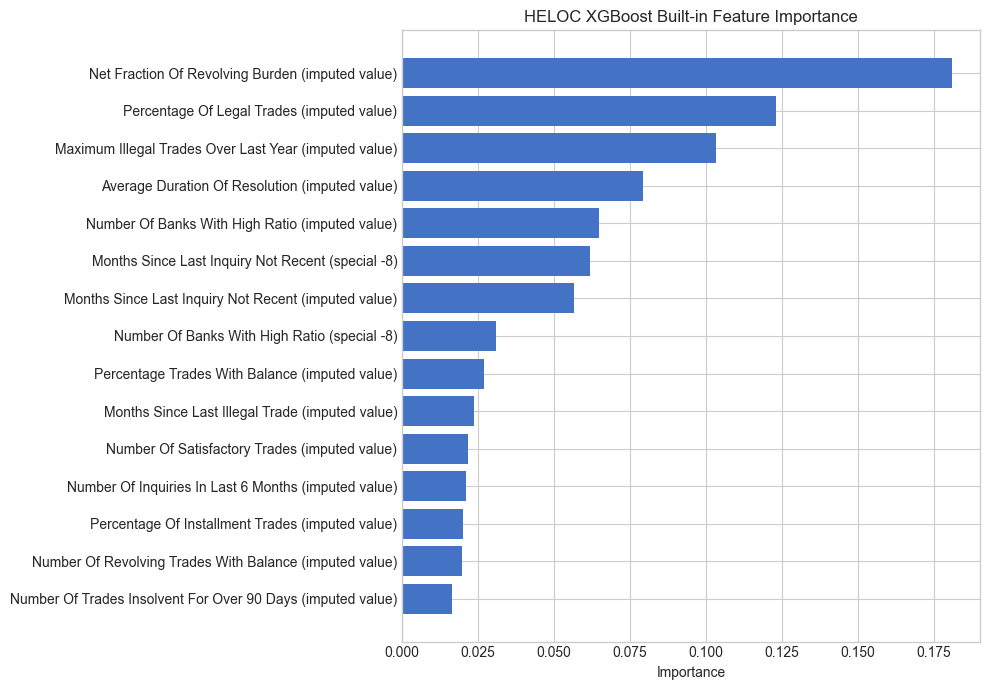

In [9]:
importance = pd.DataFrame({"transformed_feature": transformed_feature_names, "importance": final_model.feature_importances_})
importance = importance.merge(transformed_mapping, on="transformed_feature", validate="one_to_one")
importance["readable_label"] = importance.apply(
    lambda row: f"{row.display_feature} ({'imputed value' if row.representation_type == 'numeric_imputed' else f'special {int(row.special_code)}'})", axis=1)
importance = importance.sort_values("importance", ascending=False).reset_index(drop=True)
importance.insert(0, "rank", np.arange(1, len(importance) + 1))
importance.to_csv(ARTIFACT_DIR / "model_feature_importance.csv", index=False)
display(importance.head(15))

top_importance = importance.head(15).sort_values("importance")
fig, ax = plt.subplots(figsize=(10, 7)); ax.barh(top_importance.readable_label, top_importance.importance, color="#4472C4")
ax.set(title="HELOC XGBoost Built-in Feature Importance", xlabel="Importance", ylabel="")
plt.tight_layout(); plt.savefig(PLOT_DIR / "heloc_xgboost_feature_importance.png", dpi=300); plt.show()

## 10. Freeze and reproduce the final model

The selected estimator and its training-CV provenance are saved. Reloaded probabilities must reproduce the complete frozen test result.

In [10]:
MODEL_PATH = ARTIFACT_DIR / "xgboost_credit_model.joblib"
METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"
joblib.dump(final_model, MODEL_PATH)

selected_parameters = final_model.get_params()
saved_hyperparameters = {key: selected_parameters[key] for key in [
    "n_estimators", "max_depth", "learning_rate", "min_child_weight", "subsample", "colsample_bytree",
    "reg_alpha", "reg_lambda", "gamma", "objective", "eval_metric", "random_state", "n_jobs", "tree_method", "scale_pos_weight"]}
cv_metric_names = ["roc_auc", "pr_auc", "balanced_accuracy", "precision_positive", "recall_positive", "f1_positive"]
selected_cv_metrics = {metric: {"mean": float(selected_cv_row[f"mean_{metric}"]), "std": float(selected_cv_row[f"std_{metric}"])} for metric in cv_metric_names}

model_metadata = {
    "dataset": "mstz/heloc risk configuration", "xgboost_version": xgb.__version__,
    "raw_modelling_rows": 9_870, "selected_feature_count": 22, "transformed_feature_count": 33,
    "train_rows": len(X_train_processed), "test_rows": len(X_test_processed), "random_state": RANDOM_STATE,
    "decision_threshold": DECISION_THRESHOLD, "target_semantics": {"0": "not at risk", "1": "at risk"},
    "selected_model": selected_name, "selected_hyperparameters": saved_hyperparameters,
    "best_search_hyperparameters": search.best_params_, "best_search_cv_roc_auc": float(search.best_score_),
    "cv_design": {"method": "StratifiedKFold", "n_splits": 5, "shuffle": True, "random_state": 42, "scope": "training only", "search_candidates": 8},
    "selection_rule": "highest mean CV ROC-AUC; within 0.005 use PR-AUC; then balanced accuracy; then simpler model",
    "cv_selection_metrics": selected_cv_metrics, "selection_reason": selection_reason,
    "final_holdout_metrics": final_metrics, "training_time_seconds": final_training_time,
    "preprocessor_path": str(paths["preprocessor"].relative_to(PROJECT_ROOT)), "preprocessor_sha256": preprocessor_hash,
    "train_index_path": str(paths["train_indices"].relative_to(PROJECT_ROOT)), "test_index_path": str(paths["test_indices"].relative_to(PROJECT_ROOT)),
    "excluded_row_policy_reference": str(paths["row_policy"].relative_to(PROJECT_ROOT)),
    "selection_scope": "training CV only", "test_used_for_model_selection": False,
}
METADATA_PATH.write_text(json.dumps(model_metadata, indent=2), encoding="utf-8")

frozen_model = joblib.load(MODEL_PATH)
reproduced_probabilities = frozen_model.predict_proba(preprocessor.transform(raw_df.loc[test_indices, selected_features]))[:, 1]
maximum_probability_difference = float(np.max(np.abs(final_probabilities - reproduced_probabilities)))
reproduced_metrics = metric_bundle(raw_df.loc[test_indices, TARGET], reproduced_probabilities)
for key in ["roc_auc", "pr_auc", "accuracy", "balanced_accuracy", "precision_positive", "recall_positive", "f1_positive"]:
    assert np.isclose(reproduced_metrics[key], model_metadata["final_holdout_metrics"][key])
assert maximum_probability_difference <= 1e-12
print("Frozen model loaded: True")
print("Exact test rows reconstructed:", len(reproduced_probabilities))
print("Frozen predictions reproduced: True")
print("Maximum probability difference:", maximum_probability_difference)

Frozen model loaded: True
Exact test rows reconstructed: 1974
Frozen predictions reproduced: True
Maximum probability difference: 0.0


## 11. Fixed XAI evaluation cohort

Twenty deterministic test cases are selected across four probability groups. Actionability classifications remain unchanged from Stage 02.

In [11]:
case_candidates = pd.DataFrame({"row_index": X_test_raw.index.to_numpy(), "true_target": y_test.to_numpy(),
    "predicted_class": final_predictions, "predicted_probability": final_probabilities})
case_candidates["threshold_distance"] = (case_candidates.predicted_probability - DECISION_THRESHOLD).abs()
group_specs = [
    ("high-confidence positive", 1, ["predicted_probability", "row_index"], [False, True]),
    ("borderline positive", 1, ["threshold_distance", "row_index"], [True, True]),
    ("high-confidence negative", 0, ["predicted_probability", "row_index"], [True, True]),
    ("borderline negative", 0, ["threshold_distance", "row_index"], [True, True]),
]
frames, used = [], set()
for case_type, predicted_class, sort_columns, ascending in group_specs:
    available = case_candidates.loc[case_candidates.predicted_class.eq(predicted_class) & ~case_candidates.row_index.isin(used)].sort_values(sort_columns, ascending=ascending)
    if len(available) < 5: raise RuntimeError(f"Insufficient unique cases for {case_type}: {len(available)}")
    chosen = available.head(5).copy(); chosen["case_type"] = case_type; frames.append(chosen); used.update(chosen.row_index)
xai_cases = pd.concat(frames, ignore_index=True)
xai_cases.insert(0, "case_id", [f"HELOC_XAI_{number:03d}" for number in range(1, 21)])
xai_cases = xai_cases[["case_id", "row_index", "true_target", "predicted_class", "predicted_probability", "case_type"]]
xai_cases.to_csv(ARTIFACT_DIR / "xai_evaluation_cases.csv", index=False)
assert len(xai_cases) == xai_cases.row_index.nunique() == 20
display(xai_cases)
display(xai_cases.groupby("case_type").size().rename("cases").reset_index())

,case_id,row_index,true_target,predicted_class,predicted_probability,case_type
0,HELOC_XAI_001,1991,1,1,0.948322,high-confidence positive
1,HELOC_XAI_002,9808,1,1,0.945186,high-confidence positive
2,HELOC_XAI_003,1706,1,1,0.944068,high-confidence positive
3,HELOC_XAI_004,10074,1,1,0.941455,high-confidence positive
4,HELOC_XAI_005,7308,1,1,0.941175,high-confidence positive
5,HELOC_XAI_006,2151,0,1,0.500089,borderline positive
6,HELOC_XAI_007,2900,1,1,0.501511,borderline positive
7,HELOC_XAI_008,5033,0,1,0.503999,borderline positive
8,HELOC_XAI_009,8449,0,1,0.504185,borderline positive
9,HELOC_XAI_010,8777,0,1,0.504549,borderline positive


,case_type,cases
0,borderline negative,5
1,borderline positive,5
2,high-confidence negative,5
3,high-confidence positive,5


## 12. Final quality checks

The model and cohort are frozen for review. No explanation method is executed in this stage.

In [12]:
assert preprocessing_metadata["final_modelling_rows"] == 9_870
assert len(X_train_raw) == 7_896 and len(X_test_raw) == 1_974
assert len(selected_features) == 22 and X_train_processed.shape[1] == 33
assert preprocessing_metadata["preprocessor_fit_scope"] == "training_only"
assert DECISION_THRESHOLD == 0.50
assert model_metadata["selection_scope"] == "training CV only" and model_metadata["test_used_for_model_selection"] is False
assert MODEL_PATH.exists() and METADATA_PATH.exists() and len(xai_cases) == 20

print("Final modelling rows: 9,870")
print("Train rows: 7,896")
print("Test rows: 1,974")
print("Selected original features: 22")
print("Transformed features: 33")
print("New train/test split created: False")
print("Preprocessor refitted: False")
print("Training CV scope: training partition only")
print("Test used for model selection: False")
print("Decision threshold: 0.50")
print("SHAP executed: False")
print("LIME executed: False")
print("DiCE executed: False")

Final modelling rows: 9,870
Train rows: 7,896
Test rows: 1,974
Selected original features: 22
Transformed features: 33
New train/test split created: False
Preprocessor refitted: False
Training CV scope: training partition only
Test used for model selection: False
Decision threshold: 0.50
SHAP executed: False
LIME executed: False
DiCE executed: False


## 13. Stage 05 hand-off

The frozen model, preprocessor, partitions and 20-case cohort are ready for review. Stage 05 is not started here.